# 01. 농산물 도매가 EDA

예측 대상은 **품목별 일별 도매가(원/kg)** 다. 이 노트북은 모델을 만들기 전에
마트가 실제로 어떤 모양인지 확인한다.

확인할 것:
1. 커버리지와 결측 — 무엇이 없고, 없는 게 정상인지
2. 가격의 수준·분포 — 품목 간 스케일 차이
3. 계절성 — 월·절기
4. 명절 효과 — `days_to_major_holiday` (달력 피처의 핵심)
5. 공급·기상과의 관계 — 어느 변수가 실제로 가격과 움직이는지

결론은 마지막 셀에 정리한다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

from extract.database.connection import BigQueryConnection

# 한글 폰트. 없으면 축 라벨의 품목명이 네모로 깨진다.
_available = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _available:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False   # 폰트 바꾸면 마이너스가 깨진다
plt.rcParams["figure.figsize"] = (12, 4)
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

print("font:", plt.rcParams["font.family"])

font: ['AppleGothic']


In [2]:
# mart_item_daily 는 물리 테이블이 아니라 뷰다. 조회할 때마다 그 아래
# datago_shipment(284MB)를 다시 스캔하므로, 셀을 돌릴 때마다 쿼리하지 않고
# parquet 로 받아 캐시한다. 원천을 새로 적재했으면 refresh=True 로 다시 받는다.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
CACHE = ROOT / "notebooks" / ".cache" / "mart.parquet"


def load_mart(refresh: bool = False) -> pd.DataFrame:
    if CACHE.exists() and not refresh:
        return pd.read_parquet(CACHE)
    conn = BigQueryConnection()
    sql = f"SELECT * FROM `{conn.table_id('mart_item_daily')}` ORDER BY item, price_date"
    df = conn.client.query(sql).to_dataframe()
    df["price_date"] = pd.to_datetime(df["price_date"])   # dbdate 확장타입을 그대로
    # 넣으면 db_dtypes 가 로드되지 않은 환경에서 캐시를 다시 못 읽는다.
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(CACHE, index=False)
    return df


df = load_mart()
df["price_date"] = pd.to_datetime(df["price_date"])
print(f"{df.shape[0]:,}행 × {df.shape[1]}컬럼")
print(f"{df.price_date.min():%Y-%m-%d} ~ {df.price_date.max():%Y-%m-%d}")
df.head(3)

/Users/uicheol_hwang/agriquant/.venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


8,220행 × 42컬럼
2021-01-04 ~ 2026-08-06


,item,price_date,year,month,dayofweek,price_kg_avg,price_kg_med,price_kg_min,price_kg_max,price_kg_std,...,holiday_name,is_major_holiday,days_to_major_holiday,days_since_major_holiday,is_pre_holiday_week,is_market_closed,solar_term,current_solar_term,days_since_solar_term,sundry_name
0,감자,2021-01-04,2021,1,2,1696.875,1650.0,1500.0,2130.0,189.923622,...,NaN,False,38,<NA>,False,False,NaN,NaN,<NA>,NaN
1,감자,2021-01-05,2021,1,3,1754.500,1665.0,1600.0,1900.0,127.354492,...,NaN,False,37,<NA>,False,False,소한,소한,0,NaN
2,감자,2021-01-06,2021,1,4,1834.500,1715.0,1600.0,2250.0,218.396301,...,NaN,False,36,<NA>,False,False,NaN,소한,1,NaN


## 1. 커버리지와 결측

결측을 '채울 것'과 '원래 없는 것'으로 나눠 봐야 한다. 이 마트는 **가격 행을
기준(FROM)** 으로 만들어져서, 거래가 없던 날은 행 자체가 없다. 즉 여기 보이는
결측은 '가격은 있는데 딸린 값이 없는' 경우뿐이다.

In [3]:
cov = df.groupby("item").agg(
    일수=("price_date", "count"),
    시작=("price_date", "min"),
    종료=("price_date", "max"),
    기상결측=("temp_avg", lambda s: s.isna().mean()),
    출하량결측=("shipment_qty", lambda s: s.isna().mean()),
)
cov[["기상결측", "출하량결측"]] = (cov[["기상결측", "출하량결측"]] * 100).round(1)
display(cov)

# 요일 분포 — 도매시장은 평일만 열린다(1=일요일)
print("\n요일별 행 수 (1=일 … 7=토):")
print(df.dayofweek.value_counts().sort_index().to_string())

,일수,시작,종료,기상결측,출하량결측
item,,,,,
감자,1371,2021-01-04,2026-08-06,0.5,0.4
미나리,1371,2021-01-04,2026-08-06,0.5,0.7
배추,1371,2021-01-04,2026-08-06,0.5,0.6
생강,1371,2021-01-04,2026-08-06,0.5,0.6
양파,1365,2021-01-04,2026-08-06,0.5,1.0
파,1371,2021-01-04,2026-08-06,0.5,0.9



요일별 행 수 (1=일 … 7=토):
dayofweek
2    1583
3    1661
4    1643
5    1684
6    1649


## 2. 가격 수준과 분포

품목마다 단가 스케일이 크게 다르다. 한 모델로 전 품목을 학습할지, 품목별로
나눌지가 여기서 갈린다. 로그 변환이 필요한지도 분포를 봐야 판단할 수 있다.

,mean,std,min,50%,max,변동계수
item,,,,,,
배추,1205.0,560.0,473.0,1047.0,4150.0,0.46
미나리,7428.0,2873.0,2553.0,7083.0,19653.0,0.39
파,2355.0,818.0,986.0,2162.0,6092.0,0.35
생강,6760.0,2257.0,3089.0,6450.0,12140.0,0.33
양파,1230.0,353.0,468.0,1236.0,2222.0,0.29
감자,2242.0,581.0,1013.0,2172.0,4070.0,0.26


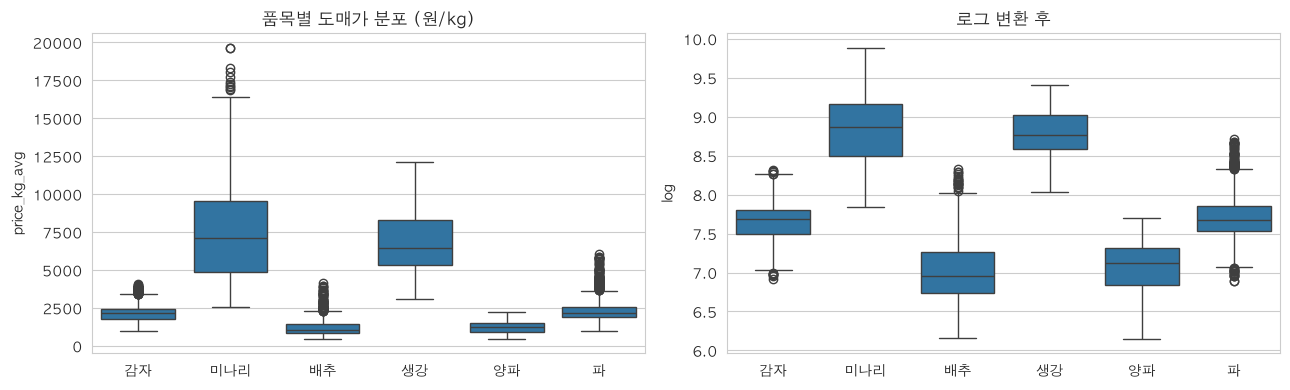

In [4]:
stat = df.groupby("item")["price_kg_avg"].describe()[["mean", "std", "min", "50%", "max"]]
stat["변동계수"] = (stat["std"] / stat["mean"]).round(2)   # 스케일 무관 변동성
_cols = ["mean", "std", "min", "50%", "max"]
stat[_cols] = stat[_cols].round(0)   # 변동계수까지 round(0) 하면 0 으로 뭉개진다
display(stat.sort_values("변동계수", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="item", y="price_kg_avg", ax=axes[0])
axes[0].set_title("품목별 도매가 분포 (원/kg)")
sns.boxplot(data=df.assign(log=np.log(df.price_kg_avg)), x="item", y="log", ax=axes[1])
axes[1].set_title("로그 변환 후")
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 3. 시계열

수준(level)이 품목별로 달라 한 축에 겹치면 안 보인다. 품목별로 나눠 그린다.
급등 구간이 어디인지, 그게 계절 때문인지 특정 해의 사건인지 눈으로 확인한다.

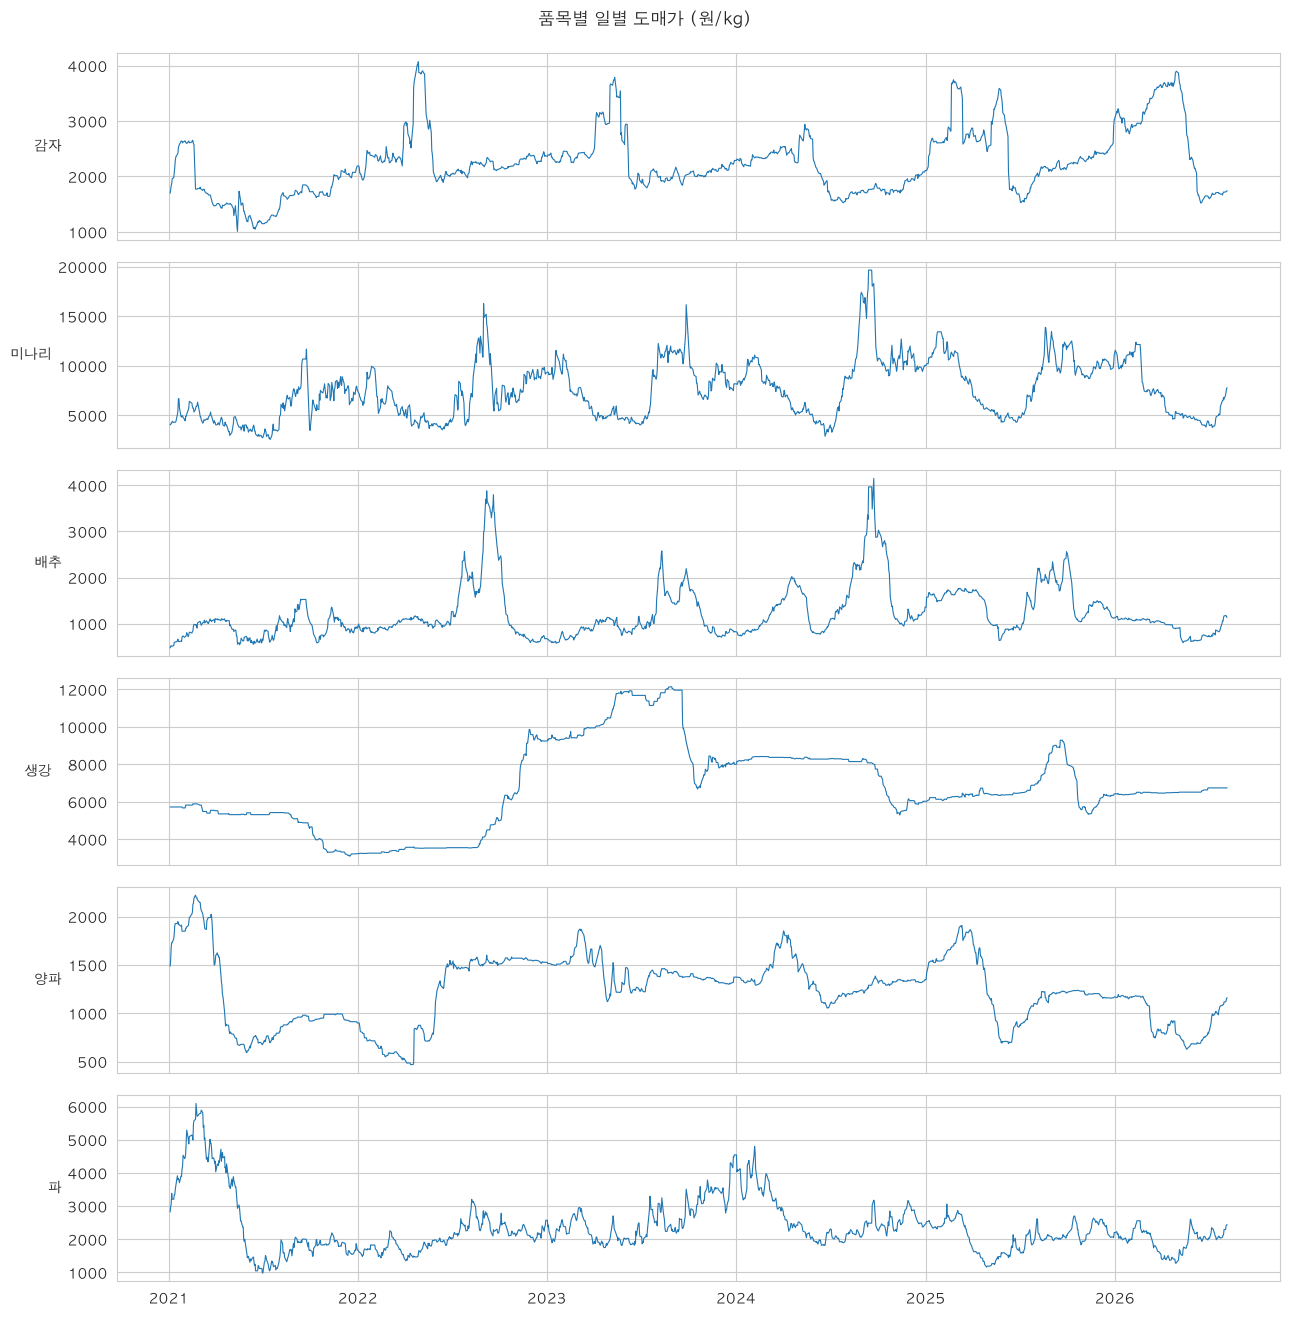

In [5]:
items = sorted(df.item.unique())
fig, axes = plt.subplots(len(items), 1, figsize=(13, 2.2 * len(items)), sharex=True)
for ax, it in zip(axes, items):
    d = df[df.item == it]
    ax.plot(d.price_date, d.price_kg_avg, lw=0.8)
    ax.set_ylabel(it, rotation=0, ha="right", va="center")
fig.suptitle("품목별 일별 도매가 (원/kg)", y=0.995)
plt.tight_layout()
plt.show()

## 4. 계절성

품목별 가격을 **그 품목의 중앙값으로 나눈 상대가격**으로 본다. 스케일이 달라
원값으로는 품목 간 비교가 안 되기 때문이다. 1.0 이 그 품목의 평상시 수준이다.

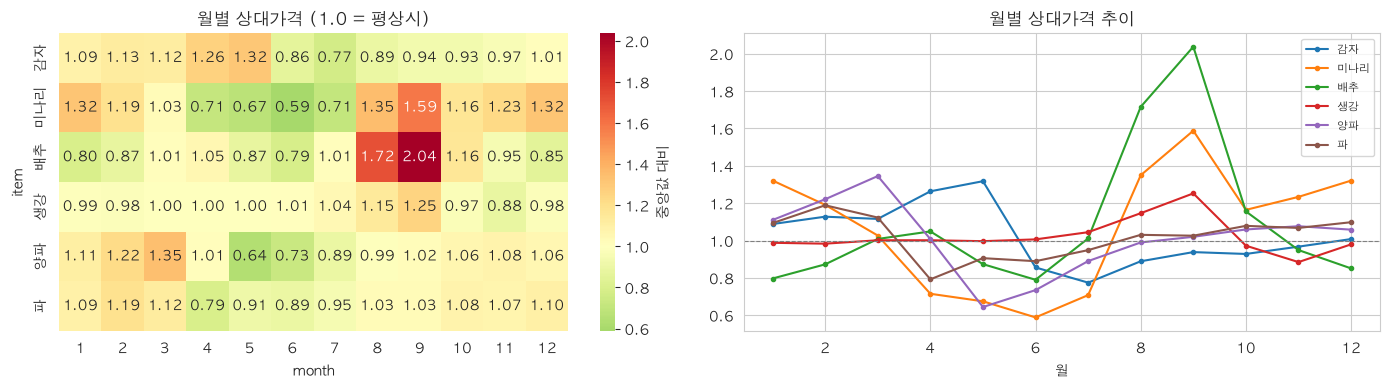

In [6]:
df["rel_price"] = df.price_kg_avg / df.groupby("item").price_kg_avg.transform("median")

pivot = df.pivot_table(index="month", columns="item", values="rel_price", aggfunc="median")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(pivot.T, annot=True, fmt=".2f", cmap="RdYlGn_r", center=1.0, ax=axes[0],
            cbar_kws={"label": "중앙값 대비"})
axes[0].set_title("월별 상대가격 (1.0 = 평상시)")
for it in items:
    axes[1].plot(pivot.index, pivot[it], marker="o", ms=3, label=it)
axes[1].axhline(1.0, color="gray", ls="--", lw=0.8)
axes[1].set_xlabel("월"); axes[1].legend(fontsize=8)
axes[1].set_title("월별 상대가격 추이")
plt.tight_layout()
plt.show()

## 5. 명절 효과

달력 피처의 핵심은 `is_public_holiday` 가 아니라 **`days_to_major_holiday`** 다.
명절 당일은 휴장이라 가격 행 자체가 없고, 값이 뛰는 건 **명절 직전**이기 때문이다.

추세를 빼고 보기 위해 **전후 60일 이동중앙값 대비 비율**을 쓴다.
`center=True` 라 미래를 참조하므로 **이건 EDA 전용이다** — 이대로 피처를 만들면
룩어헤드가 된다. 모델에서는 과거만 쓰는 형태로 다시 만들어야 한다.

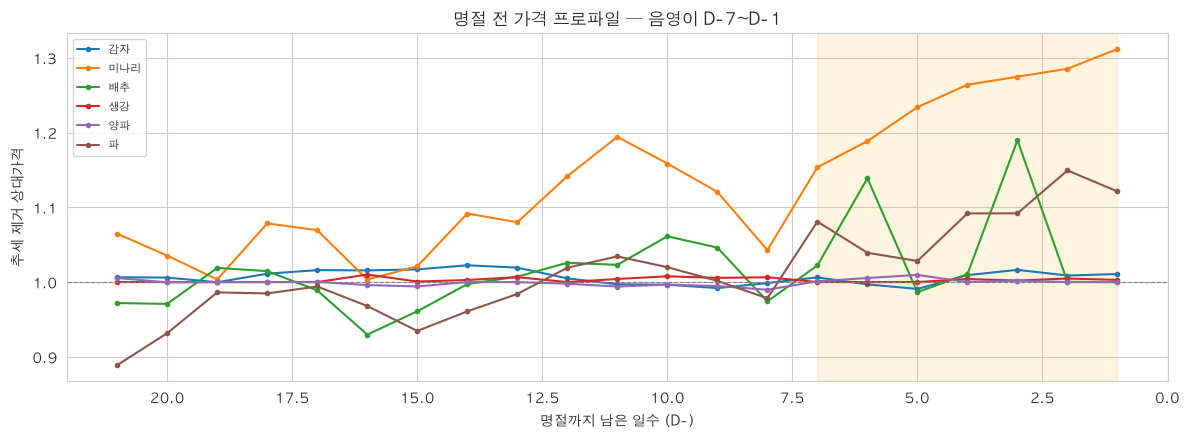

D-7~D-1 중앙 상승률 (%):
item
미나리    25.0
파       8.4
감자      0.8
배추      0.8
양파      0.1
생강      0.0


In [7]:
d = df.sort_values(["item", "price_date"]).copy()
base = d.groupby("item").price_kg_avg.transform(
    lambda s: s.rolling(60, min_periods=20, center=True).median()
)
d["detrended"] = d.price_kg_avg / base   # 1.0 = 그 시기 평상 수준

win = d[d.days_to_major_holiday.between(0, 21)]
prof = win.pivot_table(index="days_to_major_holiday", columns="item",
                       values="detrended", aggfunc="median")

fig, ax = plt.subplots(figsize=(12, 4.5))
for it in items:
    ax.plot(prof.index, prof[it], marker="o", ms=3, label=it)
ax.axhline(1.0, color="gray", ls="--", lw=0.8)
ax.axvspan(1, 7, color="orange", alpha=0.12)   # D-7 ~ D-1
ax.invert_xaxis()
ax.set_xlabel("명절까지 남은 일수 (D-)"); ax.set_ylabel("추세 제거 상대가격")
ax.set_title("명절 전 가격 프로파일 — 음영이 D-7~D-1")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("D-7~D-1 중앙 상승률 (%):")
print(((win[win.days_to_major_holiday.between(1, 7)]
        .groupby("item").detrended.median() - 1) * 100).round(1).sort_values(ascending=False).to_string())

## 6. 공급·기상과의 관계

어떤 변수가 가격과 실제로 같이 움직이는지 본다. **품목별로 따로** 봐야 한다 —
전 품목을 뭉쳐 상관을 내면 품목 간 수준 차이가 상관계수를 지배한다.

주의: 이건 동시점 상관이라 **인과도 예측력도 아니다.** 기온처럼 며칠 뒤에
효과가 나타나는 변수는 여기서 약하게 보여도 시차를 주면 달라질 수 있다.

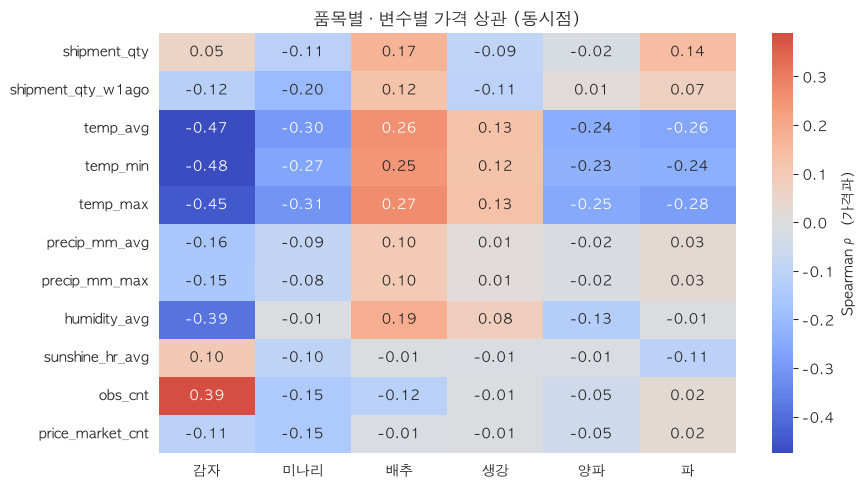

In [8]:
feats = ["shipment_qty", "shipment_qty_w1ago", "temp_avg", "temp_min", "temp_max",
         "precip_mm_avg", "precip_mm_max", "humidity_avg", "sunshine_hr_avg",
         "obs_cnt", "price_market_cnt"]

corr = pd.DataFrame({
    it: df[df.item == it][feats + ["price_kg_avg"]].corr("spearman")["price_kg_avg"].drop("price_kg_avg")
    for it in items
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "Spearman ρ (가격과)"})
ax.set_title("품목별 · 변수별 가격 상관 (동시점)")
plt.tight_layout()
plt.show()

## 7. 자기상관 — 베이스라인의 기준선

가격은 어제 가격이 오늘을 거의 설명한다. 그래서 **"어제 값 그대로"(naive)** 가
이기기 만만찮은 베이스라인이고, 어떤 모델이든 이걸 넘지 못하면 의미가 없다.
여기서 그 기준선을 미리 재 둔다.

함께 **전일과 값이 완전히 같은 날의 비율**도 본다. 이 값이 높으면 가격이
움직이는 게 아니라 원천이 갱신되지 않는 것이다. 그러면 자기상관과 naive
성능이 실력이 아니라 정체 때문에 좋아 보이므로, 그 품목은 성능을 따로 읽어야 한다.

In [9]:
rows = []
for it in items:
    s = df[df.item == it].set_index("price_date").price_kg_avg
    naive = s.shift(1)                     # 직전 거래일 값으로 예측
    err = (s - naive).abs() / s
    rows.append({
        "item": it,
        "lag1_자기상관": s.autocorr(1).round(3),
        "lag7_자기상관": s.autocorr(7).round(3),
        "전일과_동일%": round((s.diff() == 0).mean() * 100, 1),
        "naive_MAPE%": (err.mean() * 100).round(2),
    })
baseline = pd.DataFrame(rows).set_index("item")
display(baseline)
print("※ naive_MAPE 가 앞으로 만들 모델이 반드시 넘어야 할 선이다.")

,lag1_자기상관,lag7_자기상관,전일과_동일%,naive_MAPE%
item,,,,
감자,0.989,0.884,10.9,1.75
미나리,0.980,0.848,6.1,4.80
배추,0.988,0.850,5.6,3.84
생강,0.999,0.984,58.2,0.53
양파,0.996,0.947,22.6,1.36
파,0.988,0.902,6.1,3.44


※ naive_MAPE 가 앞으로 만들 모델이 반드시 넘어야 할 선이다.


## 8. 정리

### 데이터 상태

- 6품목 × 1,365~1,371일 (2021-01-04 ~ 2026-08-06), 8,220행 × 42컬럼
- **평일만 존재한다**(월~금). 도매시장이 주말·공휴일에 열리지 않아 행 자체가 없다.
  달력으로 채우면 없는 거래를 만들어내는 것이라 그대로 둔다.
- 결측은 기상 0.5%, 출하량 0.4~1.0%. 채울 이유가 없는 수준이다.

### 품목별 성격 — 하나로 묶어 다루면 안 된다

| 품목 | 변동계수 | 계절 진폭 | 명절 D-7~D-1 | 전일과 동일 | naive MAPE |
|---|---|---|---|---|---|
| 배추 | 0.46 | **2.6배** (9월 2.04 / 6월 0.79) | +0.8% | 5.6% | 3.84% |
| 미나리 | 0.39 | **2.7배** (9월 1.59 / 6월 0.59) | **+25.0%** | 6.1% | 4.80% |
| 파 | 0.35 | 1.5배 (2월 1.19 / 4월 0.79) | +8.4% | 6.1% | 3.44% |
| 생강 | 0.33 | 1.4배 (9월 1.25 / 11월 0.88) | 0.0% | **58.2%** | 0.53% |
| 양파 | 0.29 | 2.1배 (3월 1.35 / 5월 0.64) | +0.1% | **22.6%** | 1.36% |
| 감자 | 0.26 | 1.7배 (5월 1.32 / 7월 0.77) | +0.8% | 10.9% | 1.75% |

### 발견 — 모델링 설계에 직결되는 것

**1. 생강은 예측 대상으로 부적합하다.** 절반이 넘는 날(58.2%)이 전일과 값이
같다. naive MAPE 0.53% 는 예측이 쉬워서가 아니라 **원천이 갱신되지 않아서**다.
양파도 22.6% 로 경계선이다. 전 품목 평균 성능을 내면 이 둘이 지표를 끌어올려
모델이 실제보다 좋아 보인다 — **품목별로 따로 읽어야 한다.**

**2. 명절 효과는 미나리(+25.0%)와 파(+8.4%)에만 있다.** 나머지 넷은 사실상 0 이다.
`days_to_major_holiday` 를 전 품목 공통 피처로 넣으면 4개 품목에는 노이즈다.
품목별 모델이거나, 품목 × 명절 상호작용이 필요하다.

**3. 계절 진폭이 명절보다 훨씬 크다.** 배추는 9월이 6월의 2.6배다. 명절 효과
(+0.8%)와는 비교가 안 된다. 이 데이터에서 가장 강한 신호는 **계절**이고,
`month`·`current_solar_term` 이 핵심 피처가 된다.

**4. 외생변수 중에서는 기온이 가장 낫지만 그마저 약하다.**
|rho| 평균이 기온 0.26~0.28, 습도 0.14, **출하량 0.10~0.11** 이다.
공급 지표인 출하량이 이렇게 약한 건 뜻밖인데, 두 가지 가능성이 있다 —
(a) 동시점 상관이라 시차를 줘야 보인다, (b) 원천의 `avg_shipment_qty` 가
총량이 아니라 행 단위 평균이라 대리지표로서 한계가 있다.
방향도 품목별로 갈린다(감자 기온 -0.47 vs 배추 +0.26).

### 다음 노트북(02)에서 할 것

1. **시차 피처** — lag/rolling 을 **과거만 참조**하도록 (5번 셀의 룩어헤드 경고 참고)
2. **시간 순서 분할** — 랜덤 분할은 미래를 학습에 섞는다
3. **naive 대비 비교** — 품목별로. 위 표의 MAPE 가 넘어야 할 선이다
4. 출하량에 시차를 줘서 상관이 살아나는지 확인
